In [ ]:
#imports
import os
import sys
import io
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pandas as pd
import numpy as np
import joblib
from datetime import datetime
import matplotlib.pyplot as plt
import math
from contextlib import nullcontext
import time
import random

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

import torch
import torch.nn as nn
import torch.optim as optim
#from torchinfo import summary
#import torchvision.transforms.functional as F
import torch.nn.functional as F
from torchvision.transforms import InterpolationMode
from torchvision import datasets, transforms
from torch.utils.data import Subset,Dataset,DataLoader
from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights
#from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.lr_scheduler import LambdaLR
from torch.amp import GradScaler, autocast
import torch.profiler

from tqdm import tqdm

import cv2
from PIL import Image
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

: 

# Definitions

## transforms

In [6]:
transform_resnet = transforms.Compose([
                    transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ])

In [7]:
# ------------------------------
# Data Augmentation for Contrastive Learning
# ------------------------------
color_jitter = transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)

ContrastiveTransform = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([color_jitter], p=0.8),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5),
    transforms.ToTensor(),
])

In [8]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], 
    std=[0.229, 0.224, 0.225]
)
color_jitter_strength = 0.3
image_size=224
# SimCLR data augmentation transform
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=image_size, scale=(0.6, 1.0)),
    #transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(
                    brightness=color_jitter_strength,
                    contrast=color_jitter_strength,
                    saturation=color_jitter_strength,
                    hue=0.05)
            ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(5, sigma=(0.1, 0.5)),  # kernel_size ~ 0.1 * image size
    transforms.RandomAffine(degrees=3, translate=(0.02, 0.02),shear=3),
    transforms.ToTensor(),
    normalize
])

## dataloaders

In [9]:
class CustomPatchDataset(Dataset):
    def __init__(self, df,transform=ContrastiveTransform):
        """
        Args:
            image_dirs (list of str): List of directories to load images from.
            labels_df (DataFrame): DataFrame containing labeled images.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.image_files = df['file_name'].tolist()
        self.x1 = df['x'].tolist()
        self.y1 = df['y'].tolist()
        self.x2 = df['x2'].tolist()
        self.y2 = df['y2'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        x1=self.x1[idx]
        y1=self.y1[idx]
        x2=self.x2[idx]
        y2=self.y2[idx]
        image = Image.open(img_path).convert("RGB")
        patch = image.crop((x1, y1, x2, y2))

        if self.transform:
            patch1 = self.transform(patch)
            patch2 = self.transform(patch)

        return {
            'image1': patch1,
            'image2': patch2,
        }
class PatchDataset(Dataset):
    def __init__(self, df, label_column,transform=None,huggingface=True):
        """
        Args:
            image_dirs (list of str): List of directories to load images from.
            labels_df (DataFrame): DataFrame containing labeled images.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.image_files = df['file_name'].tolist()
        self.img_labels = df[label_column].tolist()
        self.img_writers = df['writer'].tolist()
        self.x1 = df['x'].tolist()
        self.y1 = df['y'].tolist()
        self.x2 = df['x2'].tolist()
        self.y2 = df['y2'].tolist()
        self.transform = transform
        self.huggingface = huggingface

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        x1=self.x1[idx]
        y1=self.y1[idx]
        x2=self.x2[idx]
        y2=self.y2[idx]
        image = Image.open(img_path).convert("RGB")
        patch = image.crop((x1, y1, x2, y2))
        writer=self.img_writers[idx]
        label = self.img_labels[idx]

        if self.huggingface:
            # the transform is actually an huggingface processor in this case
            inputs = self.transform(images=patch, return_tensors="pt")
            # Remove batch dimension from inputs
            patch = inputs['pixel_values'].squeeze()
        else:
            if self.transform:
                patch = self.transform(patch)

        return {
            'image': patch,
            'writer': int(writer),
            'label': label
        }

## model

In [10]:
class ContrastiveModel(nn.Module):
    """ResNet Backbone + Projection Head for SimCLR."""
    def __init__(self, model, in_features,projection_dim=128,hidden_dim=256):
        super().__init__()
        self.encoder = model
        self.encoder.fc = nn.Identity()  # Remove the classification head
        self.projection_head = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projection_head(features)
        return F.normalize(projections, dim=1)

## loss

In [11]:
# ------------------------------
# NT-Xent Contrastive Loss
# ------------------------------
class NTXentLoss(nn.Module):
    """Normalized Temperature-scaled Cross Entropy Loss (SimCLR)."""
    def __init__(self, temperature=0.5, verbose=False):
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()
        self.verbose = verbose

    def forward(self, z_i, z_j):
        verbose = self.verbose
        batch_size = z_i.shape[0]
        z = torch.cat([z_i, z_j], dim=0)  # Stack positive pairs
        similarity_matrix = torch.matmul(z, z.T)  # Cosine similarity
        #I don't normalize because the model already does it in the forward pass
        
        # Remove self-similarity
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        similarity_matrix = similarity_matrix[~mask].view(2 * batch_size, -1)
        if verbose:
            print("similarity_matrix: ",similarity_matrix.shape)
            print(similarity_matrix)
        
        # Compute positive pairs similarity
        '''
        positives = torch.cat([torch.diag(similarity_matrix, batch_size-1), 
                               torch.diag(similarity_matrix, -batch_size+1)], dim=0)
        '''
        
        # Compute NT-Xent loss
        #labels = torch.arange(2 * batch_size, device=z.device)
        labels = torch.cat([torch.arange(batch_size-1,2*batch_size-1, device=z.device),
                            torch.arange(batch_size, device=z.device)], dim=0)
        if verbose:
            print("labels: ",labels.shape)
            print(labels)
        
        # Each row should have the highest score at its label index to be used by the crossentropy loss
        loss = self.criterion(similarity_matrix / self.temperature, labels)
        #labels should be the class indexes. The first argument are the logits.
        return loss
    

In [12]:
class NTXentLoss_chat(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        batch_size = z_i.size(0)
        z = torch.cat([z_i, z_j], dim=0)  # [2N, D]

        # Cosine similarity matrix
        sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)  # [2N, 2N]
        sim = sim / self.temperature

        # Mask out self-similarities
        mask = torch.eye(2 * batch_size, device=z.device).bool()
        sim.masked_fill_(mask, -float('inf'))

        # Positive indices: for i in [0, 2N), positive pair is at i + N (mod 2N)
        pos_idx = torch.arange(2 * batch_size, device=z.device)
        pos_pair_idx = (pos_idx + batch_size) % (2 * batch_size)

        # Compute loss
        loss = F.cross_entropy(sim, pos_pair_idx)
        return loss


## optimizers and hyperparameters

In [13]:
'''class LARS(Optimizer):
    def __init__(self, params, lr, weight_decay=1e-6, momentum=0.9, eta=0.001, eps=1e-9):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum,
                        eta=eta, eps=eps)
        super(LARS, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                dp = p.grad.data

                if group['weight_decay'] != 0:
                    dp = dp.add(group['weight_decay'], p.data)

                param_norm = torch.norm(p.data)
                grad_norm = torch.norm(dp)
                one = torch.ones_like(param_norm)

                q = torch.where(param_norm > 0,
                                torch.where(grad_norm > 0,
                                            (group['eta'] * param_norm / (grad_norm + group['eps'])),
                                            one),
                                one)

                dp = dp.mul(q)

                if group.get('momentum', 0) > 0:
                    param_state = self.state[p]
                    if 'momentum_buffer' not in param_state:
                        buf = param_state['momentum_buffer'] = torch.clone(dp).detach()
                    else:
                        buf = param_state['momentum_buffer']
                        buf.mul_(group['momentum']).add_(dp)
                    dp = buf

                p.data.add_(-group['lr'], dp)'''

"class LARS(Optimizer):\n    def __init__(self, params, lr, weight_decay=1e-6, momentum=0.9, eta=0.001, eps=1e-9):\n        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum,\n                        eta=eta, eps=eps)\n        super(LARS, self).__init__(params, defaults)\n\n    def step(self):\n        for group in self.param_groups:\n            for p in group['params']:\n                if p.grad is None:\n                    continue\n\n                dp = p.grad.data\n\n                if group['weight_decay'] != 0:\n                    dp = dp.add(group['weight_decay'], p.data)\n\n                param_norm = torch.norm(p.data)\n                grad_norm = torch.norm(dp)\n                one = torch.ones_like(param_norm)\n\n                q = torch.where(param_norm > 0,\n                                torch.where(grad_norm > 0,\n                                            (group['eta'] * param_norm / (grad_norm + group['eps'])),\n                              

## scheduling

In [14]:
def get_cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(current_epoch):
        if current_epoch < warmup_epochs:
            return float(current_epoch) / float(max(1, warmup_epochs))
        progress = float(current_epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
        return 0.5 * (1. + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)

## train loop

### profiling

In [15]:
class TrainingProfiler:
    """Handles all profiling-related functionality"""
    
    def __init__(self, use_profiler=False, config=None):
        self.use_profiler = use_profiler
        self.config = self._get_default_config() if config is None else config
        self.profiler = None
        self.current_epoch_profiling = False
        self.traces_exported = False  # <-- Add this
        
    def _get_default_config(self):
        return {
            'profile_epochs': [1, 2],
            'profile_batches': 20,
            'output_dir': './profiler_logs',
            'profile_memory': True,
            'profile_shapes': True,
            'with_stack': True,
            'with_flops': True,
            'export_chrome_trace': True,
            'export_stacks': True,
        }
    
    def setup_profiler(self):
        """Initialize the profiler if needed"""
        if not self.use_profiler:
            return
            
        os.makedirs(self.config['output_dir'], exist_ok=True)
        self.profiler = torch.profiler.profile(
            activities=[
                torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA,
            ],
            schedule=torch.profiler.schedule(
                wait=2, #2
                warmup=2, # 2
                active=self.config['profile_batches'],# self.config['profile_batches'],
                repeat=1 #1
            ),
            on_trace_ready=torch.profiler.tensorboard_trace_handler(
                self.config['output_dir']
            ),
            record_shapes=self.config['profile_shapes'],
            profile_memory=self.config['profile_memory'],
            with_stack=self.config['with_stack'],
            with_flops=self.config['with_flops'],
        )
        #print(f"Profiler initialized with output directory: {self.config['output_dir']}")
    
    def should_profile_epoch(self, epoch):
        """Check if we should profile this epoch"""
        return (self.use_profiler and 
                epoch in self.config.get('profile_epochs', []))
    
    def start_epoch_profiling(self, epoch):
        """Start profiling for an epoch if configured"""
        self.current_epoch_profiling = self.should_profile_epoch(epoch)
        if self.current_epoch_profiling:
            print(f"🔍 Profiling enabled for epoch {epoch+1}")
            self.traces_exported = False  # Reset flag for new profiling session
            self.profiler.start()
    
    def stop_epoch_profiling(self, epoch):
        if not self.current_epoch_profiling or self.traces_exported:
            return

        self.profiler.stop()
        print(f"✅ Profiling completed for epoch {epoch+1}")

        # Only export if you did NOT use on_trace_ready handler
        # if self.config.get('export_chrome_trace', False):
        #     trace_path = os.path.join(self.config['output_dir'], f'trace_epoch_{epoch+1}.json')
        #     self.profiler.export_chrome_trace(trace_path)
        #     print(f"📊 Chrome trace exported to: {trace_path}")

        # if self.config.get('export_stacks', False):
        #     stacks_path = os.path.join(self.config['output_dir'], f'stacks_epoch_{epoch+1}.txt')
        #     self.profiler.export_stacks(stacks_path, "self_cuda_time_total")
        #     print(f"📊 Stack traces exported to: {stacks_path}")

        self.traces_exported = True
        self.profiler = None
    
    def step(self):
        """Step the profiler"""
        if self.current_epoch_profiling and self.profiler:
            #print("[Profiler] Stepping...")
            self.profiler.step()
    
    def record_function(self, name):
        """Return profiling context or nullcontext"""
        if self.current_epoch_profiling:
            return torch.profiler.record_function(name)
        return nullcontext()
    
    def cleanup(self):
        """Clean up profiler resources"""
        if self.profiler:
            self.profiler.stop()

### metrics

In [16]:
class TrainingMetrics:
    """Handles tracking and visualization of training metrics"""
    
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.train_losses = []
        self.val_losses = []
        self.val_accuracies = []
        self.learning_rates = []
        self.grad_norms = []
        self.memory_stats = []
        self.timing_stats = []
        self.best_val_loss = float('inf')
        self.epochs_without_improvement = 0
    
    def update_train_metrics(self, loss, lr, grad_norm=0):
        self.train_losses.append(loss)
        self.learning_rates.append(lr)
        self.grad_norms.append(grad_norm)
    
    def update_val_metrics(self, loss, accuracy):
        self.val_losses.append(loss)
        self.val_accuracies.append(accuracy)
    
    def update_memory_stats(self, epoch, memory_before, memory_after, epoch_time, val_time):
        self.memory_stats.append({
            'epoch': epoch,
            'memory_before_mb': memory_before,
            'memory_after_mb': memory_after,
            'memory_delta_mb': memory_after - memory_before,
            'epoch_time': epoch_time,
            'val_time': val_time
        })
    
    def update_timing_stats(self, epoch, batch, batch_time, memory_mb):
        self.timing_stats.append({
            'epoch': epoch,
            'batch': batch,
            'batch_time': batch_time,
            'memory_mb': memory_mb
        })
    
    def check_improvement(self, val_loss):
        """Check if validation loss improved and update tracking"""
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.epochs_without_improvement = 0
            return True
        else:
            self.epochs_without_improvement += 1
            return False
    
    def should_early_stop(self, patience):
        return self.epochs_without_improvement >= patience
    
    def plot_metrics(self, epoch, save_path=None):
        """Create comprehensive training plots"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Loss plots
        axes[0, 0].plot(self.train_losses, label="Train Loss")
        axes[0, 0].set_xlabel("Epoch")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].legend()
        axes[0, 0].set_title("Training Loss")

        axes[0, 1].plot(self.val_losses, label="Val Loss")
        axes[0, 1].set_xlabel("Epoch")
        axes[0, 1].set_ylabel("Loss")
        axes[0, 1].legend()
        axes[0, 1].set_title("Validation Loss")

        # Learning rate and grad norm
        axes[0, 2].plot(self.learning_rates, label="Learning Rate", color='orange')
        axes[0, 2].set_xlabel("Epoch")
        axes[0, 2].set_ylabel("LR")
        axes[0, 2].legend()
        axes[0, 2].set_title("Learning Rate")

        axes[1, 0].plot(self.grad_norms, label="Avg Grad Norm", color='green')
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("Grad Norm")
        axes[1, 0].legend()
        axes[1, 0].set_title("Gradient Norm")
        
        # Memory and timing plots
        if self.memory_stats:
            epochs_recorded = [s['epoch'] for s in self.memory_stats]
            memory_usage = [s['memory_after_mb'] for s in self.memory_stats]
            epoch_times = [s['epoch_time'] for s in self.memory_stats]
            
            axes[1, 1].plot(epochs_recorded, memory_usage, label="Memory Usage", color='red')
            axes[1, 1].set_xlabel("Epoch")
            axes[1, 1].set_ylabel("Memory (MB)")
            axes[1, 1].legend()
            axes[1, 1].set_title("GPU Memory Usage")
            
            axes[1, 2].plot(epochs_recorded, epoch_times, label="Epoch Time", color='purple')
            axes[1, 2].set_xlabel("Epoch")
            axes[1, 2].set_ylabel("Time (s)")
            axes[1, 2].legend()
            axes[1, 2].set_title("Epoch Training Time")

        plt.suptitle(f"Training Progress - Epoch {epoch+1}")
        plt.tight_layout()
        if save_path:
            plt.savefig(os.path.join(save_path, "training_plot.png"))
        plt.close()
    
    def print_summary(self):
        """Print final training summary"""
        if self.timing_stats:
            avg_batch_time = np.mean([s['batch_time'] for s in self.timing_stats])
            print(f"Average batch time: {avg_batch_time:.4f}s")
            
        if self.memory_stats:
            max_memory = max([s['memory_after_mb'] for s in self.memory_stats])
            print(f"Peak GPU memory usage: {max_memory:.2f} MB")

### checkpoints

In [17]:
class CheckpointManager:
    """Handles saving and loading of training checkpoints"""
    
    def __init__(self, checkpoint_path):
        self.checkpoint_path = checkpoint_path
    
    def save_checkpoint(self, model, optimizer, scheduler, scaler, epoch, metrics, use_amp=True):
        """Save training checkpoint"""
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': metrics.best_val_loss,
            'train_losses': metrics.train_losses,
            'val_losses': metrics.val_losses,
            'val_accuracies': metrics.val_accuracies,
            'learning_rates': metrics.learning_rates,
            'grad_norms': metrics.grad_norms,
            'memory_stats': metrics.memory_stats,
            'timing_stats': metrics.timing_stats,
        }
        
        if use_amp and scaler:
            checkpoint['scaler_state_dict'] = scaler.state_dict()
            
        torch.save(checkpoint, self.checkpoint_path)
    
    def load_checkpoint(self, model, optimizer, scheduler, scaler, metrics, device, use_amp=True):
        """Load training checkpoint and return start epoch"""
        if not os.path.exists(self.checkpoint_path):
            print(f"📂 No checkpoint found at {self.checkpoint_path}. Starting fresh training.")
            return 0 
        
        print(f"🔄 Resuming from checkpoint: {self.checkpoint_path}")
        checkpoint = torch.load(self.checkpoint_path, map_location=device, weights_only=False)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        if use_amp and scaler and 'scaler_state_dict' in checkpoint:
            scaler.load_state_dict(checkpoint['scaler_state_dict'])
        
        # Restore metrics
        metrics.train_losses = checkpoint.get('train_losses', [])
        metrics.val_losses = checkpoint.get('val_losses', [])
        metrics.val_accuracies = checkpoint.get('val_accuracies', [])
        metrics.learning_rates = checkpoint.get('learning_rates', [])
        metrics.grad_norms = checkpoint.get('grad_norms', [])
        metrics.memory_stats = checkpoint.get('memory_stats', [])
        metrics.timing_stats = checkpoint.get('timing_stats', [])
        metrics.best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        
        return checkpoint['epoch']

### others

In [18]:
def get_model_size_mb(model):
    """Calculate model size in MB"""
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    size_mb = buffer.getbuffer().nbytes / 1e6
    return size_mb

### train steps

In [19]:
def perform_training_step(model, batch, optimizer, scaler, loss_fn, device, 
                         use_amp, log_grad_norm, profiler):
    """Perform a single training step"""
    x_i, x_j = batch['image1'].to(device), batch['image2'].to(device)
    optimizer.zero_grad(set_to_none=True)
    
    grad_norm = 0
    
    with profiler.record_function("training_step"):
        if use_amp:
            with autocast(device_type='cuda'):
                with profiler.record_function("forward_pass"):
                    z_i, z_j = model(x_i), model(x_j)
                    loss = loss_fn(z_i, z_j)
                
                with profiler.record_function("backward_pass"):
                    scaler.scale(loss).backward()

                if log_grad_norm:
                    with profiler.record_function("gradient_clipping"):
                        scaler.unscale_(optimizer)
                        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0).item()

                with profiler.record_function("optimizer_step"):
                    scaler.step(optimizer)
                    scaler.update()
        else:
            with profiler.record_function("forward_pass"):
                z_i, z_j = model(x_i), model(x_j)
                loss = loss_fn(z_i, z_j)
            
            with profiler.record_function("backward_pass"):
                loss.backward()

            if log_grad_norm:
                with profiler.record_function("gradient_clipping"):
                    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0).item()

            with profiler.record_function("optimizer_step"):
                optimizer.step()
    
    return loss.detach().item(), grad_norm


def train_epoch(model, train_dataloader, optimizer, scheduler, scaler, loss_fn, 
                device, epoch, total_epochs, use_amp, log_grad_norm, profiler, metrics):
    """Train for one epoch"""
    model.train()
    epoch_train_loss = 0
    epoch_grad_norms = []
    
    # Memory tracking at epoch start
    memory_before = 0
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        memory_before = torch.cuda.memory_allocated() / 1e6
    
    loop = enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]"))
    
    for idx, batch in loop:
        batch_start_time = time.time()
        
        loss, grad_norm = perform_training_step(
            model, batch, optimizer, scaler, loss_fn, device, 
            use_amp, log_grad_norm, profiler
        )
        
        epoch_train_loss += loss
        if log_grad_norm:
            epoch_grad_norms.append(grad_norm)
        
        profiler.step()
        
        # Detailed timing and memory tracking for first few batches
        if idx < 5 or (idx % 100 == 0):
            batch_time = time.time() - batch_start_time
            if torch.cuda.is_available():
                torch.cuda.synchronize()
                current_memory = torch.cuda.memory_allocated() / 1e6
                metrics.update_timing_stats(epoch, idx, batch_time, current_memory)
    
    avg_train_loss = epoch_train_loss / len(train_dataloader)
    avg_grad_norm = np.mean(epoch_grad_norms) if epoch_grad_norms else 0
    
    return avg_train_loss, avg_grad_norm, memory_before


### validation

In [20]:
def perform_validation(model, val_dataloader, device, val_percentage, epoch, total_epochs, use_amp):
    """Perform validation using linear evaluation"""
    model.eval()
    reps, labels_list = [], []
    
    val_dataset = val_dataloader.dataset
    n_val = max(1, int(len(val_dataset) * val_percentage))
    subset_indices = random.sample(range(len(val_dataset)), n_val)

    subset = Subset(val_dataset, subset_indices)
    selected_val_batches = DataLoader(
        subset,
        batch_size=val_dataloader.batch_size,
        shuffle=False,
        num_workers=val_dataloader.num_workers,
        pin_memory=val_dataloader.pin_memory,
    )
    
    # Extract representations
    if use_amp:
        with torch.no_grad(), autocast(device_type='cuda'):
            for batch in tqdm(selected_val_batches, desc=f"Epoch {epoch+1}/{total_epochs} [Val]"):
                x, labels = batch['image'].to(device), batch['label'].to(device)
                z = model(x)
                reps.append(z.cpu().numpy())
                labels_list.append(labels.cpu().numpy())
    else:
        with torch.no_grad():
            for batch in tqdm(selected_val_batches, desc=f"Epoch {epoch+1}/{total_epochs} [Val]"):
                x, labels = batch['image'].to(device), batch['label'].to(device)
                z = model(x)
                reps.append(z.cpu().numpy())
                labels_list.append(labels.cpu().numpy())
    
    # Linear evaluation
    reps = np.concatenate(reps, axis=0)
    labels_all = np.concatenate(labels_list, axis=0)

    clf = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
    clf.fit(reps, labels_all)
    y_proba = clf.predict_proba(reps)
    val_loss = log_loss(labels_all, y_proba)
    
    if y_proba.shape[1] == 2:
        y_pred = (y_proba[:, 1] >= 0.5).astype(int)
    else:
        raise ValueError("Multiclass classification is not supported in this implementation.")
    val_acc = np.mean(y_pred == labels_all)
    
    return val_loss, val_acc

### train loops

In [21]:
def train_fine(
    model,
    train_dataloader,
    val_dataloader,
    device,
    base_lr,
    warmup_epochs=10,
    total_epochs=100,
    checkpoint_path='checkpoint.pt',
    plot_every=5,
    early_stopping_patience=10, 
    loss_fn=None,  # Will use NTXentLoss(temperature=0.5) as default
    val_percentage=0.1,
    use_profiler=False,
    profiler_config=None,
    log_grad_norm=False,
    run_epochs=2,
    save_path=None,
    use_amp=True,
):
    """
    Main training function - now much cleaner and more readable
    """
    # Setup components
    model = model.to(device)
    model_size_mb = get_model_size_mb(model)
    print(f"Model size: {model_size_mb:.2f} MB")
    
    # Initialize components
    optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs)
    scaler = GradScaler(device='cuda') if use_amp else None
    
    # Initialize helper classes
    metrics = TrainingMetrics()
    checkpoint_manager = CheckpointManager(checkpoint_path)
    checkpoint_manager_best = CheckpointManager(checkpoint_path.replace('.pt', '_best.pt'))
    
    # Load checkpoint if exists
    start_epoch = checkpoint_manager.load_checkpoint(
        model, optimizer, scheduler, scaler, metrics, device, use_amp
    )
    
    # Training loop
    for epoch in range(start_epoch, total_epochs):
        epoch_start_time = time.time()
        
        # Start epoch profiling
        # Setup profiler
        profiler = TrainingProfiler(use_profiler, profiler_config)
        profiler.setup_profiler()
        profiler.start_epoch_profiling(epoch)
        
        # Training phase
        avg_train_loss, avg_grad_norm, memory_before = train_epoch(
            model, train_dataloader, optimizer, scheduler, scaler, loss_fn,
            device, epoch, total_epochs, use_amp, log_grad_norm, profiler, metrics
        )
        
        # Stop training profiler
        profiler.stop_epoch_profiling(epoch)
        
        # Validation phase
        val_start_time = time.time()
        
        val_loss, val_acc = perform_validation(
            model, val_dataloader, device, val_percentage, epoch, total_epochs, use_amp
        )
        
        val_time = time.time() - val_start_time
        epoch_time = time.time() - epoch_start_time
        
        # Update metrics
        current_lr = optimizer.param_groups[0]['lr']
        metrics.update_train_metrics(avg_train_loss, current_lr, avg_grad_norm)
        metrics.update_val_metrics(val_loss, val_acc)
        
        # Memory tracking
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            memory_after = torch.cuda.memory_allocated() / 1e6
            metrics.update_memory_stats(epoch, memory_before, memory_after, epoch_time, val_time)
        
        # Step scheduler
        scheduler.step()
        
        # Enhanced logging
        print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Avg Grad Norm: {avg_grad_norm:.4f} | "
              f"Epoch Time: {epoch_time:.2f}s | Val Time: {val_time:.2f}s")
        
        # Check for improvement and save checkpoint
        if metrics.check_improvement(val_loss):
            checkpoint_manager_best.save_checkpoint(
                model, optimizer, scheduler, scaler, epoch, metrics, use_amp
            )
            print(f"✅ Saved new best model at epoch {epoch+1}")
        else:
            checkpoint_manager.save_checkpoint(
                model, optimizer, scheduler, scaler, epoch, metrics, use_amp
            )
            print(f"⏳ No improvement for {metrics.epochs_without_improvement} epoch(s)")
        
        # Early stopping check
        if metrics.should_early_stop(early_stopping_patience):
            print(f"⛔ Early stopping at epoch {epoch+1} (no improvement for {early_stopping_patience} epochs)")
            break
        
        # Plot metrics
        if (epoch + 1) % plot_every == 0 or (epoch + 1) == total_epochs:
            metrics.plot_metrics(epoch, save_path)
        
        # Check if we've run enough epochs
        if epoch >= start_epoch + run_epochs-1:
            print("Trained for required epochs, stopping training.")
            break
    
    # Final summary and cleanup
    print("\n📊 Performance Summary:")
    metrics.print_summary()
    #profiler.cleanup()


'''# Example usage
def example_usage():
    """Example of how to use the refactored training function"""
    
    # Configure profiling
    profiler_config = {
        'profile_epochs': [1, 10, 50],
        'profile_batches': 30,
        'profile_validation': True,
        'output_dir': './detailed_profiler_logs',
        'profile_memory': True,
        'profile_shapes': True,
        'with_stack': True,
        'with_flops': True,
        'export_chrome_trace': True,
        'export_stacks': True,
    }
    
    # Example loss function (you'll need to import/define NTXentLoss)
    from your_loss_module import NTXentLoss  # Replace with actual import
    loss_fn = NTXentLoss(temperature=0.5)
    
    # Call training function
    train_fine(
        model=your_model,
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        device=device,
        base_lr=1e-3,
        total_epochs=100,
        loss_fn=loss_fn,
        use_profiler=True,
        profiler_config=profiler_config,
        save_path='./outputs/',
        # ... other parameters
    )'''

'# Example usage\ndef example_usage():\n    """Example of how to use the refactored training function"""\n    \n    # Configure profiling\n    profiler_config = {\n        \'profile_epochs\': [1, 10, 50],\n        \'profile_batches\': 30,\n        \'profile_validation\': True,\n        \'output_dir\': \'./detailed_profiler_logs\',\n        \'profile_memory\': True,\n        \'profile_shapes\': True,\n        \'with_stack\': True,\n        \'with_flops\': True,\n        \'export_chrome_trace\': True,\n        \'export_stacks\': True,\n    }\n    \n    # Example loss function (you\'ll need to import/define NTXentLoss)\n    from your_loss_module import NTXentLoss  # Replace with actual import\n    loss_fn = NTXentLoss(temperature=0.5)\n    \n    # Call training function\n    train_fine(\n        model=your_model,\n        train_dataloader=train_loader,\n        val_dataloader=val_loader,\n        device=device,\n        base_lr=1e-3,\n        total_epochs=100,\n        loss_fn=loss_fn,\n 

In [22]:
def train_lars(model, dataloader, device, n_epochs):
    model = model.to(device)

    base_lr = 4.8
    batch_size = 4096
    effective_lr = base_lr * (batch_size / 256)
    optimizer = LARS(model.parameters(), lr=effective_lr, weight_decay=1e-6)
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_epochs=10, total_epochs=100)

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for (x1, x2) in tqdm(dataloader, desc=f"Epoch {epoch+1}"):
            x = torch.cat([x1, x2], dim=0).to(device)

            z = model(x)
            loss = NTXentLoss(z)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()
        print(f"Epoch {epoch+1} Loss: {epoch_loss / len(dataloader):.4f}")

In [23]:
def train_val(
    model,
    train_dataloader,
    val_dataloader,
    device,
    base_lr,
    warmup_epochs=10,
    total_epochs=100,
    checkpoint_path='checkpoint.pt',
    plot_every=5,
    early_stopping_patience=10, loss_fn=NTXentLoss(temperature=0.5),
):
    model = model.to(device)
    def get_model_size_mb(model):
        buffer = io.BytesIO()
        torch.save(model.state_dict(), buffer)
        size_mb = buffer.getbuffer().nbytes / 1e6
        return size_mb

    model_size_mb = get_model_size_mb(model)
    print(f"Model size: {model_size_mb:.2f} MB")

    optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, warmup_epochs=warmup_epochs, total_epochs=total_epochs
    )
    loss_fn = loss_fn

    # Initialize tracking variables
    start_epoch = 0
    train_losses = []
    val_losses = []
    lrs = []
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    # Optional Resume from checkpoint
    if os.path.exists(checkpoint_path):
        print(f"🔄 Resuming from checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_val_loss = checkpoint['best_val_loss']
        train_losses = checkpoint.get('train_losses', [])
        val_losses = checkpoint.get('val_losses', [])
        lrs = checkpoint.get('lrs', [])
    else:
        print(f"📂 No checkpoint found at {checkpoint_path}. Starting fresh training.")

    for epoch in range(start_epoch, total_epochs):
        model.train()
        epoch_train_loss = 0

        for idx,batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]")):
            x_i, x_j = batch['image1'].to(device), batch['image2'].to(device)
            z_i, z_j = model(x_i), model(x_j)
            loss = loss_fn(z_i, z_j)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            
            optimizer.step()
            '''del x_i, x_j, z_i, z_j, loss  # clear references
            torch.cuda.empty_cache()  # optional, helps if memory gets fragmented'''

            epoch_train_loss += loss.item()

            '''if idx % 50 == 0:  # Print every 100 batches
                before = torch.cuda.memory_allocated() / 1e6
                before_reserved = torch.cuda.memory_reserved() / 1e6
                print(f"[GPU Memory] Allocated: {before:.2f} MB | Reserved: {before_reserved:.2f} MB")'''

        avg_train_loss = epoch_train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)
        lrs.append(optimizer.param_groups[0]['lr'])

        # Validation
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{total_epochs} [Val]"):
                x_i, x_j = batch['image1'].to(device), batch['image2'].to(device)
                z_i, z_j = model(x_i), model(x_j)
                loss = loss_fn(z_i, z_j)
                epoch_val_loss += loss.item()
        avg_val_loss = epoch_val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)

        scheduler.step()

        # Logging
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {lrs[-1]:.6f}")

        # Checkpointing based on val loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_loss': best_val_loss,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'lrs': lrs
            }
            torch.save(checkpoint, checkpoint_path)
            epochs_without_improvement = 0
            print(f"✅ Saved new best model at epoch {epoch+1}")
        else:
            epochs_without_improvement += 1
            print(f"⏳ No improvement for {epochs_without_improvement} epoch(s)")

        # Early stopping
        if epochs_without_improvement >= early_stopping_patience:
            print(f"⛔ Early stopping at epoch {epoch+1} (no improvement for {early_stopping_patience} epochs)")
            break

        # Plot every `plot_every` epochs
        if (epoch + 1) % plot_every == 0 or (epoch + 1) == total_epochs:
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label="Train Loss")
            plt.plot(val_losses, label="Val Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(lrs, label="Learning Rate", color='orange')
            plt.xlabel("Epoch")
            plt.ylabel("LR")
            plt.legend()

            plt.suptitle(f"Epoch {epoch+1}")
            plt.tight_layout()
            plt.show()


In [24]:
def train(
    model,
    train_dataloader,
    device,
    base_lr,
    warmup_epochs=10,
    total_epochs=100,
    checkpoint_path='checkpoint.pt',
    plot_every=5,
    early_stopping_patience=10, loss_fn=NTXentLoss(temperature=0.5),
):
    model = model.to(device)
    def get_model_size_mb(model):
        buffer = io.BytesIO()
        torch.save(model.state_dict(), buffer)
        size_mb = buffer.getbuffer().nbytes / 1e6
        return size_mb

    model_size_mb = get_model_size_mb(model)
    print(f"Model size: {model_size_mb:.2f} MB")

    optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, warmup_epochs=warmup_epochs, total_epochs=total_epochs
    )
    loss_fn = loss_fn

    # Initialize tracking variables
    start_epoch = 0
    train_losses = []
    lrs = []
    best_train_loss = float('inf')
    epochs_without_improvement = 0

    # Optional Resume from checkpoint
    if os.path.exists(checkpoint_path):
        print(f"🔄 Resuming from checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_train_loss = checkpoint['best_val_loss']
        train_losses = checkpoint.get('train_losses', [])
        lrs = checkpoint.get('lrs', [])
    else:
        print(f"📂 No checkpoint found at {checkpoint_path}. Starting fresh training.")

    for epoch in range(start_epoch, total_epochs):
        model.train()
        epoch_train_loss = 0

        for idx,batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]")):
            x_i, x_j = batch['image1'].to(device), batch['image2'].to(device)
            z_i, z_j = model(x_i), model(x_j)
            loss = loss_fn(z_i, z_j)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            
            optimizer.step()
            '''del x_i, x_j, z_i, z_j, loss  # clear references
            torch.cuda.empty_cache()  # optional, helps if memory gets fragmented'''

            epoch_train_loss += loss.item()

            '''if idx % 50 == 0:  # Print every 100 batches
                before = torch.cuda.memory_allocated() / 1e6
                before_reserved = torch.cuda.memory_reserved() / 1e6
                print(f"[GPU Memory] Allocated: {before:.2f} MB | Reserved: {before_reserved:.2f} MB")'''

        avg_train_loss = epoch_train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)
        lrs.append(optimizer.param_groups[0]['lr'])

        scheduler.step()

        # Logging
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | LR: {lrs[-1]:.6f}")

        # Checkpointing based on train loss
        if avg_train_loss < best_train_loss:
            best_train_loss = avg_train_loss
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_train_loss': best_train_loss,
                'train_losses': train_losses,
                'lrs': lrs
            }
            torch.save(checkpoint, checkpoint_path)
            epochs_without_improvement = 0
            print(f"✅ Saved new best model at epoch {epoch+1}")
        else:
            epochs_without_improvement += 1
            print(f"⏳ No improvement for {epochs_without_improvement} epoch(s)")

        # Early stopping
        if epochs_without_improvement >= early_stopping_patience:
            print(f"⛔ Early stopping at epoch {epoch+1} (no improvement for {early_stopping_patience} epochs)")
            break

        # Plot every `plot_every` epochs
        if (epoch + 1) % plot_every == 0 or (epoch + 1) == total_epochs:
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label="Train Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(lrs, label="Learning Rate", color='orange')
            plt.xlabel("Epoch")
            plt.ylabel("LR")
            plt.legend()

            plt.suptitle(f"Epoch {epoch+1}")
            plt.tight_layout()
            plt.show()

In [25]:
def pretrain_contrastive(model, dataloader, optimizer, device, epochs=10):
    model.train()
    loss_fn = NTXentLoss()
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            x_i, x_j = batch['image1'], batch['image2']
            x_i, x_j = x_i.to(device), x_j.to(device)
            z_i, z_j = model(x_i), model(x_j)
            loss = loss_fn(z_i, z_j)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(dataloader):.4f}")

## t-sne visualization

In [26]:
'''# After pretraining
features, labels = [], []
with torch.no_grad():
    for x, y in dataloader:
        x = x.to(device)
        z = model(x)
        features.append(z.cpu())
        labels.append(y)
# Plot t-SNE of concatenated features'''

'# After pretraining\nfeatures, labels = [], []\nwith torch.no_grad():\n    for x, y in dataloader:\n        x = x.to(device)\n        z = model(x)\n        features.append(z.cpu())\n        labels.append(y)\n# Plot t-SNE of concatenated features'

## measure

In [27]:
def get_size_of_image_on_model(model, device, input_shape=(3, 224, 224), contrastive=True,batches=5):
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    before = torch.cuda.memory_allocated() / 1e6
    before_reserved = torch.cuda.memory_reserved() / 1e6
    print(f"[GPU Memory] Allocated before model loading: {before:.2f} MB | Reserved: {before_reserved:.2f} MB")
    model = model.to(device)
    after = torch.cuda.memory_allocated() / 1e6
    after_reserved = torch.cuda.memory_reserved() / 1e6
    print(f"[GPU Memory] Allocated after model loading: {after:.2f} MB | Reserved: {after_reserved:.2f} MB")
    print(f"[GPU Memory] DELTA: {after-before:.2f} MB | Reserved: {after_reserved-before_reserved:.2f} MB")
    print("-" * 50)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, warmup_epochs=10, total_epochs=100
    )
    loss_fn = NTXentLoss()

    model.train()
    batch = {
        'image1': torch.rand((batches, *input_shape), device=device),
        'image2': torch.rand((batches, *input_shape), device=device)
    }
    x_i, x_j = batch['image1'].to(device), batch['image2'].to(device)
    allocated_image = tensor_memory_mb(x_i)
    print(f"x_i memory: {allocated_image:.2f} MB")
    print('batch size:', x_i.shape[0])

    before = torch.cuda.memory_allocated() / 1e6
    before_reserved = torch.cuda.memory_reserved() / 1e6
    print(f"[GPU Memory] Allocated before model forward pass: {before:.2f} MB | Reserved: {before_reserved:.2f} MB")
    z_i, z_j = model(x_i), model(x_j)
    after = torch.cuda.memory_allocated() / 1e6
    after_reserved = torch.cuda.memory_reserved() / 1e6
    print(f"[GPU Memory] Allocated after model forward pass: {after:.2f} MB | Reserved: {after_reserved:.2f} MB")
    print(f"[GPU Memory] DELTA: {after-before:.2f} MB | Reserved: {after_reserved-before_reserved:.2f} MB")
    print("-" * 50)
    if contrastive:
        loss = loss_fn(z_i, z_j)
    else:
        loss = F.mse_loss(z_i, z_j)
    optimizer.zero_grad(set_to_none=True)
    before = torch.cuda.memory_allocated() / 1e6
    before_reserved = torch.cuda.memory_reserved() / 1e6
    print(f"[GPU Memory] Allocated before backward pass: {before:.2f} MB | Reserved: {before_reserved:.2f} MB")
    loss.backward()
    after = torch.cuda.memory_allocated() / 1e6
    after_reserved = torch.cuda.memory_reserved() / 1e6
    print(f"[GPU Memory] Allocated after backward pass: {after:.2f} MB | Reserved: {after_reserved:.2f} MB")
    print(f"[GPU Memory] DELTA: {after-before:.2f} MB | Reserved: {after_reserved-before_reserved:.2f} MB")
    print("-" * 50)
'''
import gc
import torch
import objgraph

gc.collect()
tensors = [obj for obj in gc.get_objects() if torch.is_tensor(obj) and obj.is_cuda]

print(f"Found {len(tensors)} CUDA tensors occupying memory:")
for i, t in enumerate(tensors):
print(f"Tensor {i}: shape={t.shape}, dtype={t.dtype}, size={t.element_size() * t.nelement() / 1024**2:.2f} MB")'''

'\nimport gc\nimport torch\nimport objgraph\n\ngc.collect()\ntensors = [obj for obj in gc.get_objects() if torch.is_tensor(obj) and obj.is_cuda]\n\nprint(f"Found {len(tensors)} CUDA tensors occupying memory:")\nfor i, t in enumerate(tensors):\nprint(f"Tensor {i}: shape={t.shape}, dtype={t.dtype}, size={t.element_size() * t.nelement() / 1024**2:.2f} MB")'

In [28]:
get_size_of_image_on_model(
    ContrastiveModel(resnet50(weights=ResNet50_Weights.IMAGENET1K_V2), in_features=2048, projection_dim=128),
    device='cuda',
    input_shape=(3, 224, 224), contrastive = True, batches = 1 
)
print("$$" * 50)
get_size_of_image_on_model(
    ContrastiveModel(resnet50(weights=ResNet50_Weights.IMAGENET1K_V2), in_features=2048, projection_dim=128),
    device='cuda',
    input_shape=(3, 224, 224), contrastive = True, batches = 32
)
print(torch.cuda.memory_summary(device='cuda', abbreviated=True))

[GPU Memory] Allocated before model loading: 0.00 MB | Reserved: 0.00 MB
[GPU Memory] Allocated after model loading: 97.03 MB | Reserved: 123.73 MB
[GPU Memory] DELTA: 97.03 MB | Reserved: 123.73 MB
--------------------------------------------------
x_i memory: 0.57 MB
batch size: 1
[GPU Memory] Allocated before model forward pass: 98.24 MB | Reserved: 125.83 MB
[GPU Memory] Allocated after model forward pass: 278.83 MB | Reserved: 308.28 MB
[GPU Memory] DELTA: 180.59 MB | Reserved: 182.45 MB
--------------------------------------------------
[GPU Memory] Allocated before backward pass: 278.83 MB | Reserved: 308.28 MB
[GPU Memory] Allocated after backward pass: 214.00 MB | Reserved: 394.26 MB
[GPU Memory] DELTA: -64.83 MB | Reserved: 85.98 MB
--------------------------------------------------
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
[GPU Memory] Allocated before model loading: 17.04 MB | Reserved: 41.94 MB
[GPU Memory] Allocat

In [29]:
get_size_of_image_on_model(
    ContrastiveModel(resnet18(weights='IMAGENET1K_V1'), in_features=512, projection_dim=128),
    device='cuda',
    input_shape=(3, 224, 224)
)

[GPU Memory] Allocated before model loading: 17.04 MB | Reserved: 41.94 MB
[GPU Memory] Allocated after model loading: 62.88 MB | Reserved: 90.18 MB
[GPU Memory] DELTA: 45.84 MB | Reserved: 48.23 MB
--------------------------------------------------
x_i memory: 2.87 MB
batch size: 5
[GPU Memory] Allocated before model forward pass: 68.90 MB | Reserved: 90.18 MB
[GPU Memory] Allocated after model forward pass: 292.26 MB | Reserved: 312.48 MB
[GPU Memory] DELTA: 223.36 MB | Reserved: 222.30 MB
--------------------------------------------------
[GPU Memory] Allocated before backward pass: 292.27 MB | Reserved: 312.48 MB
[GPU Memory] Allocated after backward pass: 115.28 MB | Reserved: 390.07 MB
[GPU Memory] DELTA: -176.99 MB | Reserved: 77.59 MB
--------------------------------------------------


# Initialization

In [30]:
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [31]:
test=False
test_number = 16*32
source_file="icdar_train_df_iam_rimes_patches_20250615_170212.csv"
val_file = 'icdar_train_df_patches_20250515_164130.csv' #gw=5 m_patches=5
running = 'new-laptop'
saved = 'new-laptop'
running_val = 'new-laptop'
saved_val = 'old-laptop'
pretrained = True
selected_model='resnet50'
train_df = pd.read_csv(f"{source_path}\\outputs\\preprocessed_data\\{source_file}")
train_df=file_IO.change_filename_from_to(train_df, fr=saved, to=running)

val_huggingface = False
p_val = 0.9
use_all = True
N_val=282

In [32]:
#cahtgpt suggests
base_lr = 3e-4
total_epochs = 150
weight_decay=1e-6
batch_size = 64
temperature=0.5
checkpoint_path = f"{source_path}\\outputs\\models\\contrastive\\checkpoint.pt"
save_path = f"{source_path}\\outputs\\models\\contrastive\\"
p_train=0.9
log_grad_norm = True
use_profiler = True
run_epochs = 8
plot_every = 5
patience = 20
warmup_epochs = 10
use_amp = True #mixed precision training
val_percentage= 0.1 #percentage of validation data used for linear evaluation
num_workers = 0
pin_memory = True

In [33]:
profiler_config = {
        'profile_epochs': list(range(0, total_epochs, 10)),  # Profile every 10 epochs
        'profile_batches': 30,
        'output_dir': save_path+'detailed_profiler_logs',
        'profile_memory': True,
        'profile_shapes': True,
        'with_stack': True,
        'with_flops': True,
        'export_chrome_trace': True,
        'export_stacks': True,
    }

In [34]:
if selected_model == 'resnet50':
    weights = ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
    model = resnet50(weights=weights)
else:
    raise ValueError(f"Model {selected_model} is not supported.")
in_features = model.fc.in_features
print(f"Model in_features: {in_features}")

Model in_features: 2048


In [35]:
if test:
    train_dataset = CustomPatchDataset(train_df[:test_number],transform=simclr_transform)
else:
    train_dataset = CustomPatchDataset(train_df ,transform=simclr_transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=pin_memory)

#val_dataset = CustomPatchDataset(train_df[(train_df['train']==0) & (train_df['index']<=N_max)] , transform=simclr_transform)
#val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [36]:
val_transform = transform_resnet
val_df = pd.read_csv(f"{source_path}\\outputs\\preprocessed_data\\{val_file}")
val_df=file_IO.change_filename_from_to(val_df, fr=saved_val, to=running_val)
val_df = val_df.drop(columns=['train'])
if use_all:
    val_df['train'] = 0
else:
    pages_df = pd.DataFrame({'writer': np.arange(1, N_val+1)})
    pages_df['train'] = np.random.choice([0, 1], size=len(pages_df), p=[1-p_val, p_val])
    # Merge with the train_df dataframe on the writer column
    val_df = val_df.merge(pages_df, on='writer', how='left')
if test:
    val_dataset = PatchDataset(val_df[(val_df['train']==0) & (val_df['writer']<=N_val)][:test_number] , 'male', transform=val_transform, huggingface=val_huggingface)
else:
    val_dataset = PatchDataset(val_df[(val_df['train']==0) & (val_df['writer']<=N_val)] , 'male', transform=val_transform, huggingface=val_huggingface)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=int(num_workers/2),     # Parallel workers
    pin_memory=pin_memory )

In [37]:
'''# Create an iterator
data_iter = iter(train_dataloader)
# Get a single batch
batch = next(data_iter)
plot_image_batches(batch['image1'], batch['image2'])'''

"# Create an iterator\ndata_iter = iter(train_dataloader)\n# Get a single batch\nbatch = next(data_iter)\nplot_image_batches(batch['image1'], batch['image2'])"

In [38]:
contrastive_model = ContrastiveModel(model, in_features=in_features,projection_dim=128)

# run

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(f"[GPU Memory] Allocated: {torch.cuda.memory_allocated() / 1e6:.2f} MB | Reserved: {torch.cuda.memory_reserved() / 1e6:.2f} MB")

cuda
[GPU Memory] Allocated: 17.04 MB | Reserved: 390.07 MB


In [ ]:
loss_fn = NTXentLoss(temperature=temperature)

# Call training function
train_fine(
    model=contrastive_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    device=device,
    base_lr=base_lr,
    total_epochs=total_epochs,
    loss_fn=loss_fn,
    use_profiler=use_profiler,
    profiler_config=profiler_config,
    save_path=save_path,
    plot_every=plot_every,
    early_stopping_patience=patience,
    warmup_epochs=warmup_epochs,
    checkpoint_path=checkpoint_path,
    log_grad_norm=log_grad_norm,
    run_epochs=run_epochs,
    use_amp=use_amp,
    val_percentage=val_percentage,  # Use 10% of validation data for linear evaluation
    # ... other parameters
)
    

Model size: 96.58 MB
🔄 Resuming from checkpoint: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\models\contrastive\checkpoint.pt


Epoch 109/150 [Val]: 100%|██████████| 9/9 [00:42<00:00,  4.69s/it]
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Epoch 109 Train Loss: 2.8884 | Val Acc: 0.6454 | Val Loss: 0.6128 | LR: 0.000062 | Avg Grad Norm: inf | Epoch Time: 1344.48s | Val Time: 42.26s
⏳ No improvement for 1 epoch(s)


Epoch 110/150 [Val]: 100%|██████████| 9/9 [00:42<00:00,  4.67s/it]
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Epoch 110 Train Loss: 2.8847 | Val Acc: 0.7039 | Val Loss: 0.5831 | LR: 0.000059 | Avg Grad Norm: inf | Epoch Time: 1234.40s | Val Time: 42.03s
⏳ No improvement for 2 epoch(s)
🔍 Profiling enabled for epoch 111


Epoch 111/150 [Train]:   6%|▌         | 33/558 [01:21<22:13,  2.54s/it]

In [ ]:
# call tensorboard --logdir="C:/Users/andre/VsCode/PD related projects/gender_detection/outputs/models/contrastive/detailed_profiler_logs"
tensorboard --logdir=./detailed_profiler_logs

In [ ]:
1/0

ZeroDivisionError: division by zero

In [ ]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
!nvidia-smi

Mon Jun 16 17:45:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.52                 Driver Version: 576.52         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   40C    P8              7W /   55W |    7935MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# save

In [ ]:
experiment = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = os.path.join(source_path, "outputs", "logs")
# Example usage:
LOG_OUT_FILE = out_dir+"\\feature_extraction_metadata_log.json"
print(f"Log file path: {LOG_OUT_FILE}")
file_IO.add_or_update_experiment(
    experiment, LOG_OUT_FILE,
    custom_metadata={
        "original raw file": source_data,
        "input file": input_file_name,
        "FE model": model_used,
        "FE transform": transform_used,
        "classifier model": selected_model,
        "model_params": feature_extraction_model[selected_model].get_params(),
        "n_splits": n_splits,
        "train_on_language": train_on_language,
        "train_on_same": train_on_same,
        "task": task,
        "with cross validation": with_cross_validation,
        "with PCA": with_pca,
        "training time for cross-validation": time_taken_cross_val,
        "training time for final model": time_taken,
        "cross_val_accuracies": cross_val_accuracies,
        "subgroup_accuracies": subgroup_accuracies,
        "is_kaggle": is_kaggle,
        "test": 'this is a test column',
        "description": ''' I am training a classifier on the feature vectors extracted by a deep model
        I am evaluating the results on subsets of the training data, based on language and same/different text.''' 
    }
)

# random tests

## tests on transformations

In [172]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], 
    std=[0.229, 0.224, 0.225]
)
color_jitter_strength = 0.3
image_size=224
# SimCLR data augmentation transform
strong_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=image_size, scale=(0.6, 1.0)),
    #transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(brightness=color_jitter_strength,contrast=color_jitter_strength,saturation=color_jitter_strength,
                   hue=0.05)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(5, sigma=(0.1, 0.5)),  # kernel_size ~ 0.1 * image size'''
    transforms.RandomAffine(degrees=3, translate=(0.02, 0.02), shear=5),
    transforms.ToTensor(),
    normalize
])

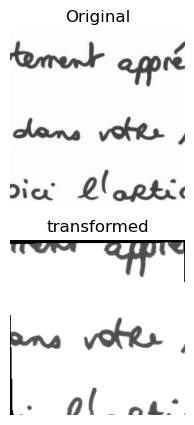

In [263]:
i = 1000  # Change this index as needed
image_path = train_df.iloc[i]['file_name']
x1 = train_df.iloc[i]['x']
y1 = train_df.iloc[i]['y']
x2 = train_df.iloc[i]['x2']
y2 = train_df.iloc[i]['y2']
img = Image.open(image_path).convert('RGB').crop((x1, y1, x2, y2))

def show_images(original, transformed1):
    fig, axs = plt.subplots(2, figsize=(15, 5))
    axs[0].imshow(original)
    axs[0].set_title("Original")
    axs[0].axis('off')

    axs[1].imshow(transformed1.permute(1, 2, 0).numpy())
    axs[1].set_title("transformed")
    axs[1].axis('off')

    plt.show()

# Apply transforms
transformed = strong_transform(img)

# Normalize back to [0,1] for display
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

show_images(
    img,
    denormalize(transformed)
)

## tests on contrastive learning

In [78]:
class RandomTensorDataset(Dataset):
    def __init__(self, num_samples, image_size=(256, 256, 3)):
        self.num_samples = num_samples
        self.image_size = image_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        tensor1 = torch.rand(*self.image_size).permute(2, 0, 1)  # Convert to (C, H, W)
        #tensor2 = torch.rand(*self.image_size).permute(2, 0, 1)  # Convert to (C, H, W)
        tensor2 = tensor1.clone()
        return tensor1, tensor2

# Create the dataset and dataloader
random_dataset = RandomTensorDataset(num_samples=1000)
random_dataloader = DataLoader(random_dataset, batch_size=15, shuffle=True)

# Example: Fetch a batch
random_batch = next(iter(random_dataloader))
print(f"Batch tensor1 shape: {random_batch[0].shape}")
print(f"Batch tensor2 shape: {random_batch[1].shape}")

Batch tensor1 shape: torch.Size([15, 3, 256, 256])
Batch tensor2 shape: torch.Size([15, 3, 256, 256])


In [79]:
weights = ResNet50_Weights.IMAGENET1K_V1 
model = resnet50(weights=weights)
contrastive_model = ContrastiveModel(model, in_features=2048, projection_dim=128)

In [80]:
x_i,x_j = random_batch[0],random_batch[1]
z_i, z_j = contrastive_model(x_i), contrastive_model(x_j)
print(f"Batch representation1 shape: {z_i.shape}")
print(f"Batch representation2 shape: {z_j.shape}")

Batch representation1 shape: torch.Size([15, 128])
Batch representation2 shape: torch.Size([15, 128])


In [81]:
print(z_i[0]-z_j[0])

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SubBackward0>)


In [82]:
loss_fn = NTXentLoss(verbose=True)
loss = loss_fn(z_i, z_j)

similarity_matrix:  torch.Size([30, 29])
tensor([[0.8167, 0.8420, 0.8287, 0.8028, 0.8629, 0.7963, 0.8248, 0.7954, 0.8657,
         0.8111, 0.8016, 0.8066, 0.8522, 0.8174, 1.0000, 0.8167, 0.8420, 0.8287,
         0.8028, 0.8629, 0.7963, 0.8248, 0.7954, 0.8657, 0.8111, 0.8016, 0.8066,
         0.8522, 0.8174],
        [0.8167, 0.8960, 0.8702, 0.8418, 0.8371, 0.8495, 0.8287, 0.7845, 0.8557,
         0.8522, 0.8757, 0.8707, 0.8549, 0.8304, 0.8167, 1.0000, 0.8960, 0.8702,
         0.8418, 0.8371, 0.8495, 0.8287, 0.7845, 0.8557, 0.8522, 0.8757, 0.8707,
         0.8549, 0.8304],
        [0.8420, 0.8960, 0.9105, 0.9053, 0.8980, 0.8769, 0.8923, 0.8544, 0.9001,
         0.9072, 0.9003, 0.8951, 0.8972, 0.8924, 0.8420, 0.8960, 1.0000, 0.9105,
         0.9053, 0.8980, 0.8769, 0.8923, 0.8544, 0.9001, 0.9072, 0.9003, 0.8951,
         0.8972, 0.8924],
        [0.8287, 0.8702, 0.9105, 0.8745, 0.8567, 0.8216, 0.8514, 0.8208, 0.8700,
         0.8743, 0.8419, 0.8471, 0.8542, 0.8427, 0.8287, 0.8702, 0.9105

In [83]:
loss_fn = NTXentLoss_chat()
loss_2 = loss_fn(z_i, z_j)

In [84]:
print(loss, loss_2)

tensor(3.0918, grad_fn=<NllLossBackward0>) tensor(3.0918, grad_fn=<NllLossBackward0>)


# easy access

In [3]:
def reload_modules():
    import importlib
    import utils.image_processing as image_processing
    import utils.file_IO as file_IO
    import utils.visualization as visualization
    import utils.tests as tests
    import utils.data_loading as data_loading
    import utils.utils_transforms as u_transforms

    importlib.reload(data_loading)
    importlib.reload(file_IO)
    importlib.reload(image_processing)
    importlib.reload(visualization)
    importlib.reload(tests)
    importlib.reload(u_transforms)

    return image_processing, file_IO, visualization, tests, data_loading, u_transforms
image_processing, file_IO, visualization, tests, data_loading, u_transforms = reload_modules()

In [4]:
def plot_image_batches(batch1, batch2, n=8, figsize=(16, 4)):
    """
    Plots two batches of images: first row is batch1, second row is batch2.
    Args:
        batch1 (Tensor): Batch of images (B, C, H, W)
        batch2 (Tensor): Batch of images (B, C, H, W)
        n (int): Number of images to plot from each batch
        figsize (tuple): Figure size
    """
    import matplotlib.pyplot as plt

    n = min(n, batch1.shape[0], batch2.shape[0])
    fig, axes = plt.subplots(2, n, figsize=figsize)
    memory=0
    for i in range(n):
        img1 = batch1[i].cpu()
        img2 = batch2[i].cpu()
        # Unnormalize if needed (assuming ImageNet stats)
        '''if img1.shape[0] == 3:
            img1 = img1 * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            img2 = img2 * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            img1 = img1.clamp(0,1)
            img2 = img2.clamp(0,1)'''
        axes[0, i].imshow(img1.permute(1, 2, 0).numpy())
        axes[0, i].axis('off')
        axes[1, i].imshow(img2.permute(1, 2, 0).numpy())
        axes[1, i].axis('off')
        memory += 2*tensor_memory_mb(img1)
    axes[0, 0].set_ylabel('Batch 1', fontsize=14)
    axes[1, 0].set_ylabel('Batch 2', fontsize=14)
    plt.tight_layout()
    plt.show()
    print(f"Memory used for plotting: {memory:.2f} MB")

In [5]:
def tensor_memory_mb(tensor):
    """Returns memory occupied by a torch tensor in megabytes (MB)."""
    num_bytes = tensor.element_size() * tensor.nelement()
    return num_bytes / (1024 ** 2)

# Example usage:
# memory_mb = tensor_memory_mb(batch['image1'])
# print(f"Memory occupied: {memory_mb:.2f} MB")